In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Setup Successful!")

Setup Successful!


In [24]:
# ==========================================
# Import Required Libraries
# ==========================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [25]:
# ==========================================
# Load Dataset
# ==========================================

TRAIN_PATH = "../data/UNSW_NB15_training-set.csv"
TEST_PATH = "../data/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)

Training Dataset Shape : (82332, 45)
Testing Dataset Shape  : (175341, 45)


In [26]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


In [27]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  str    
 3   service            82332 non-null  str    
 4   state              82332 non-null  str    
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             82332 non-null

In [28]:
print(train_df.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [29]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,82332.0,4.116650e+04,2.376735e+04,1.0,20583.750000,4.116650e+04,6.174925e+04,8.233200e+04
dur,82332.0,1.006756e+00,4.710444e+00,0.0,0.000008,1.413800e-02,7.193603e-01,5.999999e+01
spkts,82332.0,1.866647e+01,1.339164e+02,1.0,2.000000,6.000000e+00,1.200000e+01,1.064600e+04
dpkts,82332.0,1.754594e+01,1.155741e+02,0.0,0.000000,2.000000e+00,1.000000e+01,1.101800e+04
sbytes,82332.0,7.993908e+03,1.716423e+05,24.0,114.000000,5.340000e+02,1.280000e+03,1.435577e+07
dbytes,82332.0,1.323379e+04,1.514715e+05,0.0,0.000000,1.780000e+02,9.560000e+02,1.465753e+07
rate,82332.0,8.241089e+04,1.486204e+05,0.0,28.606114,2.650177e+03,1.111111e+05,1.000000e+06
sttl,82332.0,1.809677e+02,1.015134e+02,0.0,62.000000,2.540000e+02,2.540000e+02,2.550000e+02
dttl,82332.0,9.571300e+01,1.166677e+02,0.0,0.000000,2.900000e+01,2.520000e+02,2.530000e+02
sload,82332.0,6.454902e+07,1.798618e+08,0.0,11202.466797,5.770032e+05,6.514286e+07,5.268000e+09


In [30]:
missing = train_df.isnull().sum()

missing = missing[missing > 0]

print(missing)


Series([], dtype: int64)


In [31]:
print("Duplicate rows :", train_df.duplicated().sum())

Duplicate rows : 0


In [32]:
train_df.dtypes.value_counts()

int64      30
float64    11
str         4
Name: count, dtype: int64

In [33]:
numerical_columns = train_df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = train_df.select_dtypes(include=["object"]).columns

print("Numerical Features :", len(numerical_columns))
print("Categorical Features :", len(categorical_columns))

print("\nCategorical Columns")
print(categorical_columns)

Numerical Features : 41
Categorical Features : 4

Categorical Columns
Index(['proto', 'service', 'state', 'attack_cat'], dtype='str')


In [34]:
train_df["label"].value_counts()

label
1    45332
0    37000
Name: count, dtype: int64

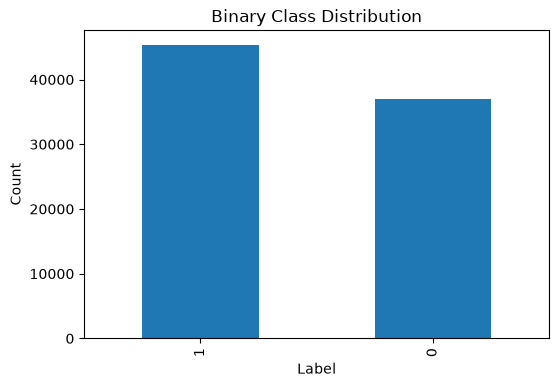

In [35]:
plt.figure(figsize=(6,4))

train_df["label"].value_counts().plot(
    kind="bar"
)

plt.title("Binary Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.savefig("../figures/eda_binary_class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [36]:
train_df["attack_cat"].value_counts()

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

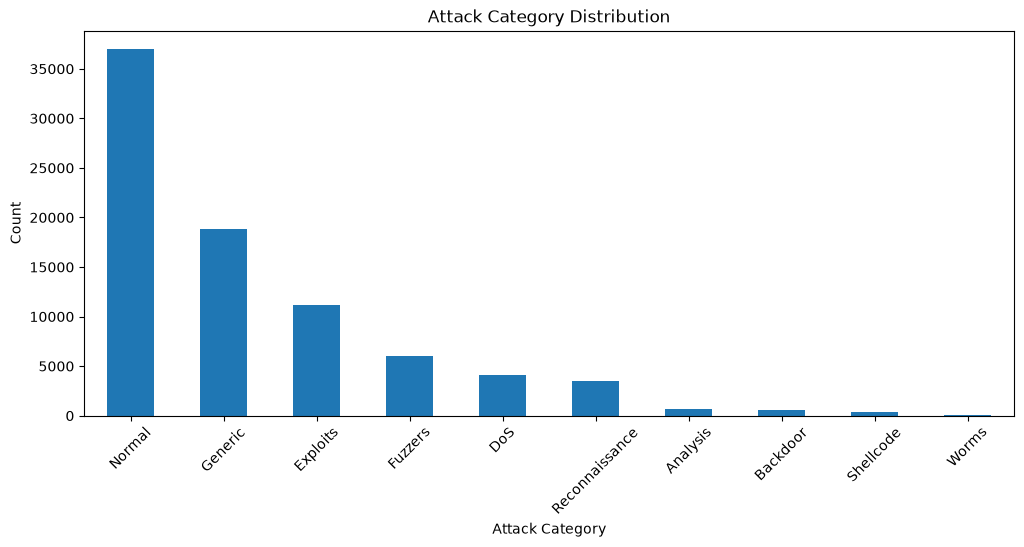

In [37]:
plt.figure(figsize=(12,5))

train_df["attack_cat"].value_counts().plot(
    kind="bar"
)

plt.title("Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.savefig("../figures/eda_attack_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
summary = pd.DataFrame({

    "Column":train_df.columns,
    "Datatype":train_df.dtypes.values,
    "Missing":train_df.isnull().sum().values,
    "Unique":train_df.nunique().values

})

summary

,Column,Datatype,Missing,Unique
0,id,int64,0,82332
1,dur,float64,0,39888
2,proto,str,0,131
3,service,str,0,13
4,state,str,0,7
5,spkts,int64,0,420
6,dpkts,int64,0,436
7,sbytes,int64,0,4489
8,dbytes,int64,0,4034
9,rate,float64,0,40616


## Correlation analysis

Identify highly correlated numeric features (|r| > 0.95) — these are candidates to drop during preprocessing to reduce redundancy, per the proposal's data-analysis plan.

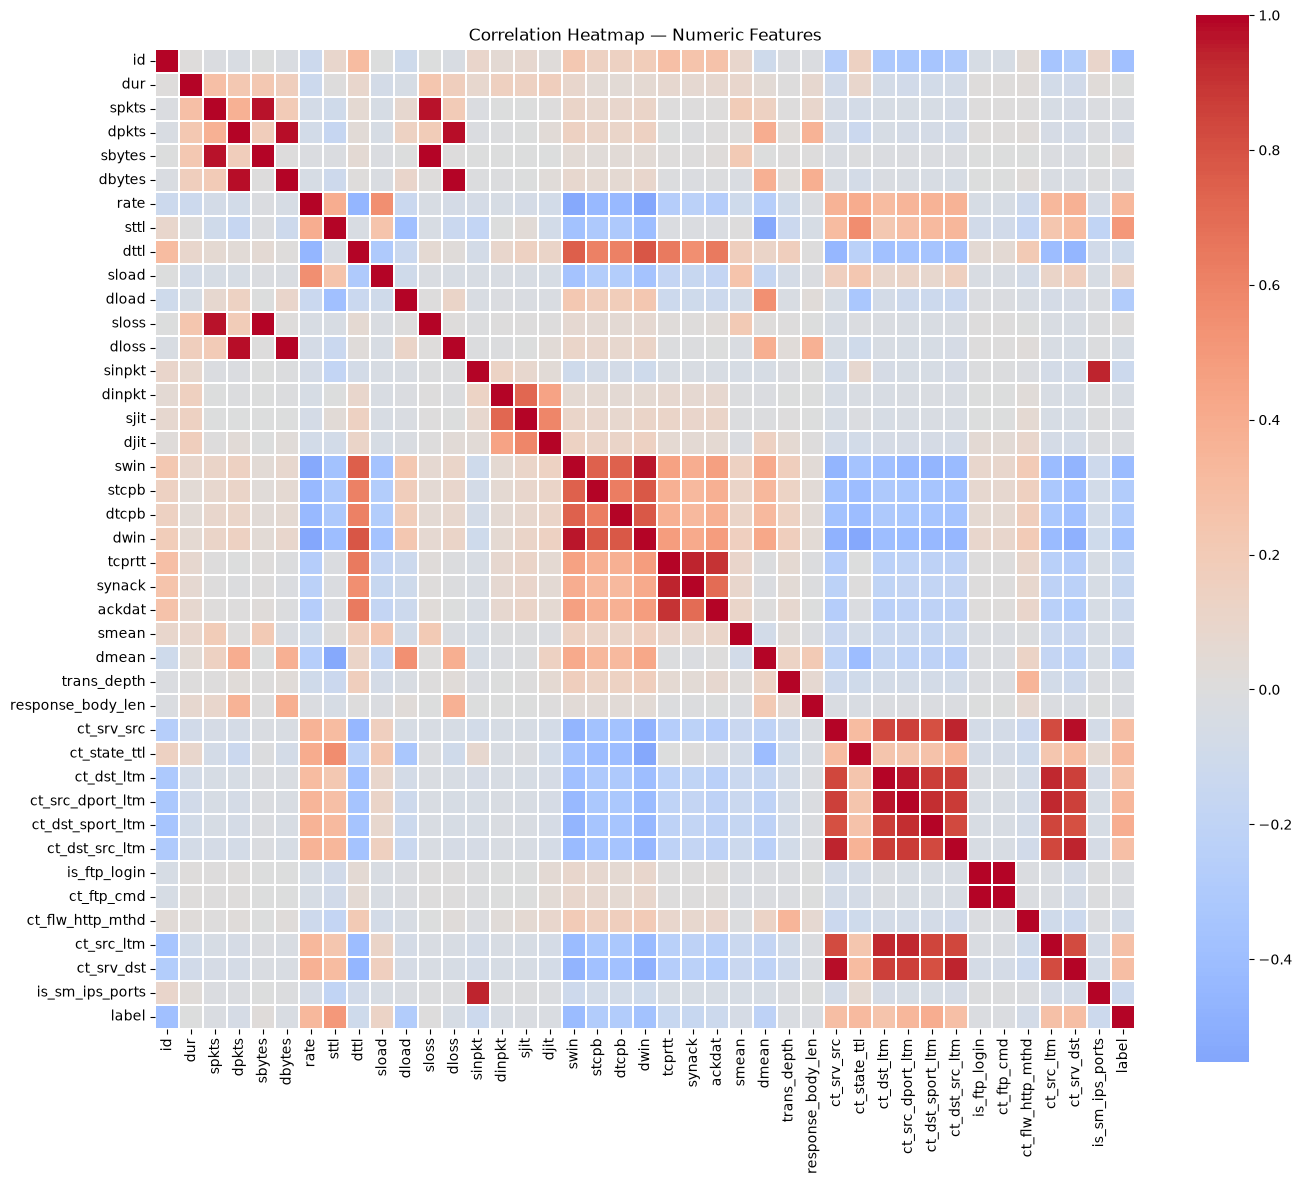

Feature pairs with |r| > 0.95: 10
  spkts  <->  sbytes   r = 0.966
  spkts  <->  sloss   r = 0.974
  dpkts  <->  dbytes   r = 0.976
  dpkts  <->  dloss   r = 0.982
  sbytes  <->  sloss   r = 0.995
  dbytes  <->  dloss   r = 0.997
  swin  <->  dwin   r = 0.96
  ct_srv_src  <->  ct_srv_dst   r = 0.978
  ct_dst_ltm  <->  ct_src_dport_ltm   r = 0.96
  is_ftp_login  <->  ct_ftp_cmd   r = 0.994


In [39]:
import seaborn as sns

corr_matrix = train_df[numerical_columns].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, linewidths=0.3)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("../figures/eda_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Flag pairs with |correlation| > 0.95 (one of each pair is a drop candidate)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

print(f"Feature pairs with |r| > 0.95: {len(high_corr_pairs)}")
for a, b, r in high_corr_pairs:
    print(f"  {a}  <->  {b}   r = {r}")


## Outlier detection

Boxplots of numeric features to visually check for outliers, per the proposal's data-analysis plan.

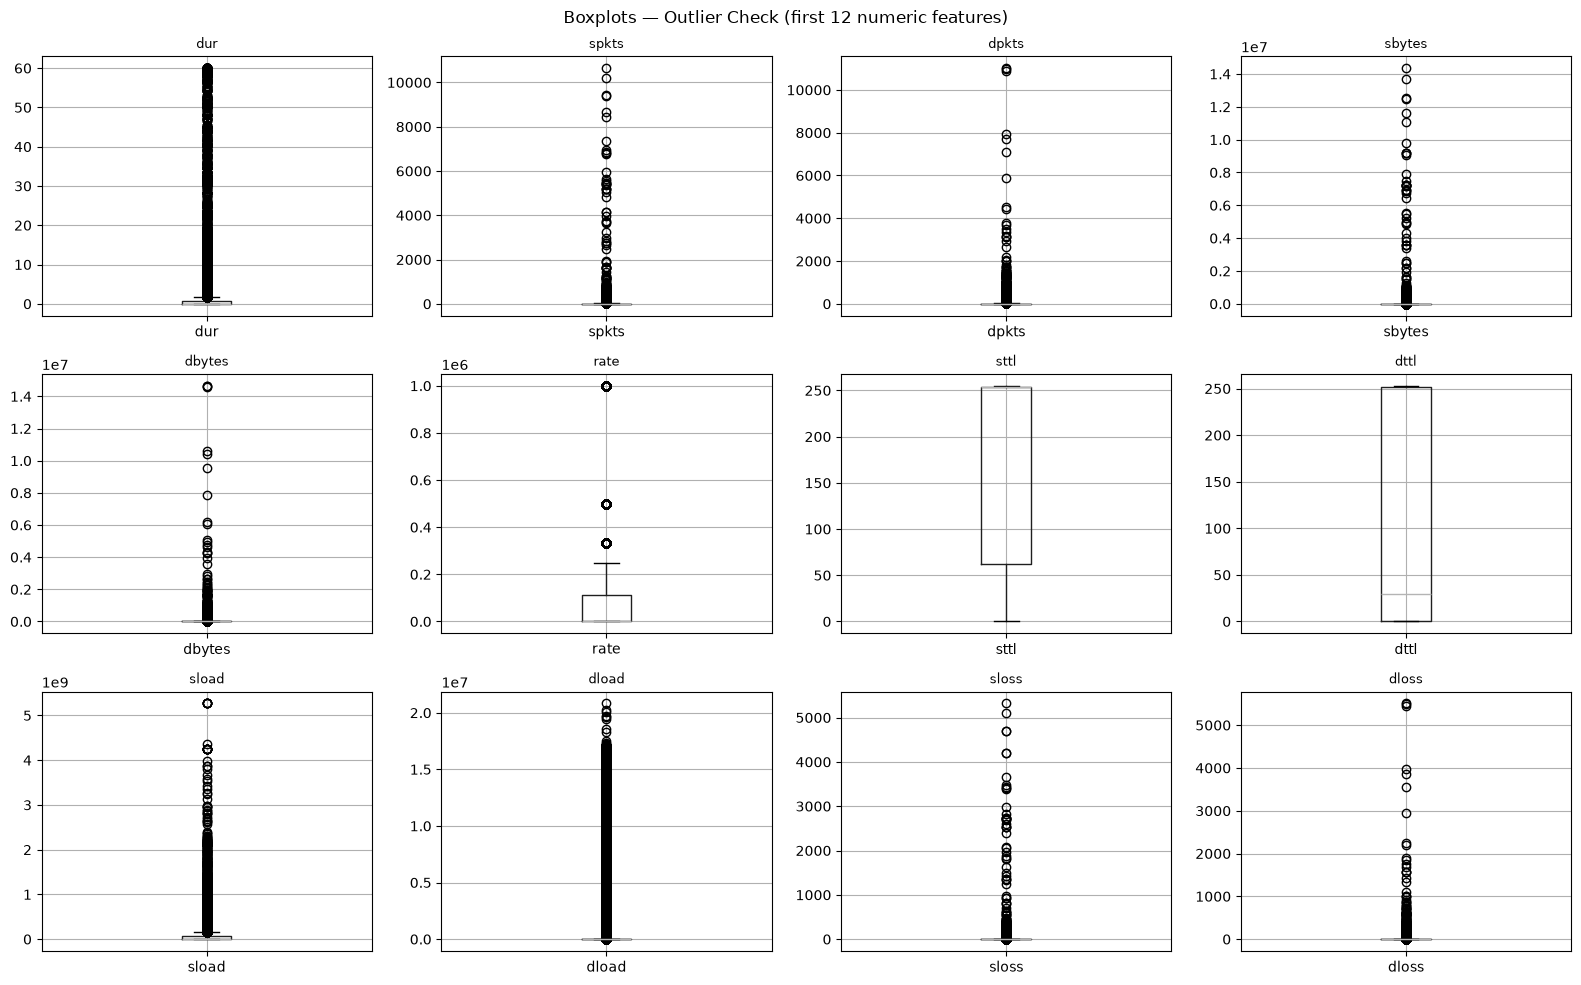

In [40]:
# Boxplots for the first 12 numeric features (grid), scaled individually
# so differing units/ranges don't hide outliers on shared axes.
plot_cols = [c for c in numerical_columns if c not in ("id",)][:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), plot_cols):
    train_df.boxplot(column=col, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")

for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")

plt.suptitle("Boxplots — Outlier Check (first 12 numeric features)")
plt.tight_layout()
plt.savefig("../figures/eda_outlier_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()
